In [1]:
import numpy as np
import matplotlib.pyplot as plt

**1. CREATE XOR DATASET**

In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("Input X:")
print(X)

print("\nOutput y:")
print(y)


Input X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output y:
[[0.]
 [1.]
 [1.]
 [0.]]


**2. KERAS IMPLEMENTATION**

In [5]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_history = keras_model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

keras_predictions = keras_model.predict(X, verbose=0)

print("Keras Predictions:")
for i in range(len(X)):
    predicted_class = 1 if keras_predictions[i][0] >= 0.5 else 0

    print(
        X[i],
        "Actual =", int(y[i][0]),
        "Probability =", round(float(keras_predictions[i][0]), 4),
        "Predicted =", predicted_class
    )

loss, accuracy = keras_model.evaluate(X, y, verbose=0)

print("\nKeras Loss:", round(loss, 4))
print("Keras Accuracy:", round(accuracy * 100, 2), "%")

Keras Predictions:
[0. 0.] Actual = 0 Probability = 0.0001 Predicted = 0
[0. 1.] Actual = 1 Probability = 0.9999 Predicted = 1
[1. 0.] Actual = 1 Probability = 0.4999 Predicted = 0
[1. 1.] Actual = 0 Probability = 0.5001 Predicted = 1

Keras Loss: 0.3467
Keras Accuracy: 50.0 %


**3. PYTORCH IMPLEMENTATION**

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

X_torch = torch.tensor(X)
y_torch = torch.tensor(y)

class XORNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

torch_model = XORNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(
    torch_model.parameters(),
    lr=0.05
)

torch_losses = []
torch_accuracies = []

for epoch in range(1000):

    output = torch_model(X_torch)
    loss = criterion(output, y_torch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())
    predicted = (output >= 0.5).float()
    accuracy = (predicted == y_torch).float().mean().item()

    torch_accuracies.append(accuracy)
with torch.no_grad():
    torch_predictions = torch_model(X_torch)

print("PyTorch Predictions:")

for i in range(len(X)):
    predicted_class = 1 if torch_predictions[i][0] >= 0.5 else 0

    print(
        X[i],
        "Actual =", int(y[i][0]),
        "Probability =", round(float(torch_predictions[i][0]), 4),
        "Predicted =", predicted_class
    )
with torch.no_grad():

    predicted = (torch_predictions >= 0.5).float()

    accuracy = (
        predicted == y_torch
    ).float().mean().item()

print("\nPyTorch Loss:", round(torch_losses[-1], 4))
print("PyTorch Accuracy:", round(accuracy * 100, 2), "%")

PyTorch Predictions:
[0. 0.] Actual = 0 Probability = 0.0002 Predicted = 0
[0. 1.] Actual = 1 Probability = 0.9999 Predicted = 1
[1. 0.] Actual = 1 Probability = 0.9999 Predicted = 1
[1. 1.] Actual = 0 Probability = 0.0001 Predicted = 0

PyTorch Loss: 0.0001
PyTorch Accuracy: 100.0 %


**4. TENSORFLOW LOW-LEVEL API**

In [9]:
tf.random.set_seed(42)
W1 = tf.Variable(
    tf.random.normal([2, 4], stddev=0.5)
)
b1 = tf.Variable(
    tf.zeros([4])
)

W2 = tf.Variable(
    tf.random.normal([4, 1], stddev=0.5)
)

b2 = tf.Variable(
    tf.zeros([1])
)
def forward_pass(X):
    hidden = tf.matmul(X, W1) + b1
    hidden = tf.nn.tanh(hidden)
    output = tf.matmul(hidden, W2) + b2
    output = tf.nn.sigmoid(output)

    return output

def calculate_loss(y_true, y_pred):

    loss = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(loss)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.05
)

tf_losses = []
tf_accuracies = []

for epoch in range(1000):

    with tf.GradientTape() as tape:

        predictions = forward_pass(X)

        loss = calculate_loss(
            y,
            predictions
        )

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )
    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )
    tf_losses.append(float(loss))
    predicted_classes = tf.cast(
        predictions >= 0.5,
        tf.float32
    )

    accuracy = tf.reduce_mean(
        tf.cast(
            predicted_classes == y,
            tf.float32
        )
    )

    tf_accuracies.append(float(accuracy))

tf_predictions = forward_pass(X)

print("TensorFlow Low-Level Predictions:")

for i in range(len(X)):

    predicted_class = (
        1 if tf_predictions[i][0] >= 0.5 else 0
    )

    print(
        X[i],
        "Actual =", int(y[i][0]),
        "Probability =", round(float(tf_predictions[i][0]), 4),
        "Predicted =", predicted_class
    )

print(
    "\nTensorFlow Loss:",
    round(tf_losses[-1], 4)
)

print(
    "TensorFlow Accuracy:",
    round(tf_accuracies[-1] * 100, 2),
    "%"
)

TensorFlow Low-Level Predictions:
[0. 0.] Actual = 0 Probability = 0.0 Predicted = 0
[0. 1.] Actual = 1 Probability = 0.9991 Predicted = 1
[1. 0.] Actual = 1 Probability = 0.9998 Predicted = 1
[1. 1.] Actual = 0 Probability = 0.0008 Predicted = 0

TensorFlow Loss: 0.0005
TensorFlow Accuracy: 100.0 %


**5. COMPARE TRAINING CURVES**

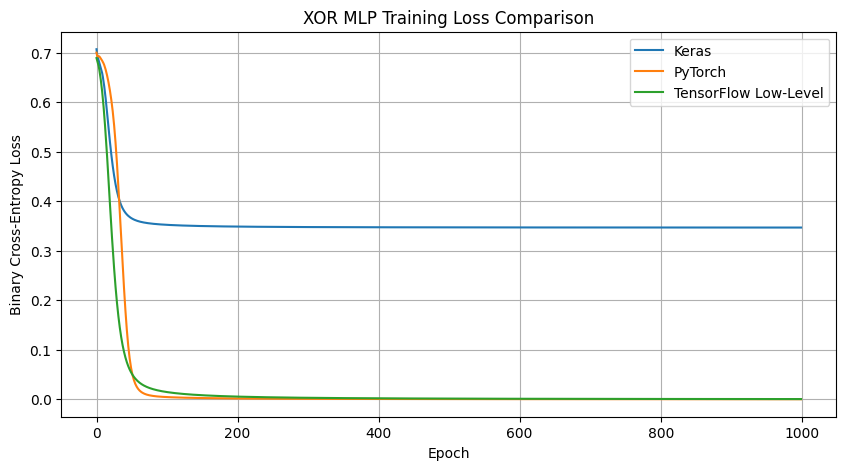

In [10]:

plt.figure(figsize=(10, 5))

plt.plot(
    keras_history.history["loss"],
    label="Keras"
)

plt.plot(
    torch_losses,
    label="PyTorch"
)

plt.plot(
    tf_losses,
    label="TensorFlow Low-Level"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("XOR MLP Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()


All three models quickly reduce the loss close to zero which shows that they successfully learned the XOR function


**6. COMPARE ACCURACY**

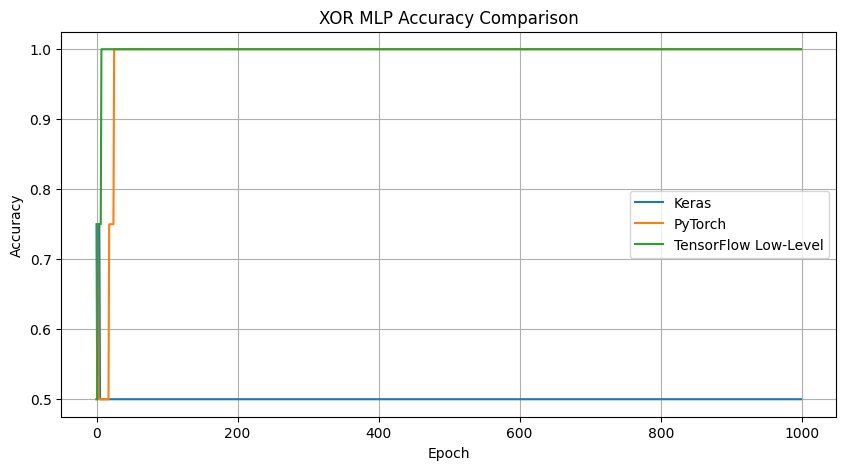

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    keras_history.history["accuracy"],
    label="Keras"
)

plt.plot(
    torch_accuracies,
    label="PyTorch"
)

plt.plot(
    tf_accuracies,
    label="TensorFlow Low-Level"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("XOR MLP Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

From your graph, PyTorch and TensorFlow reach 100% accuracy while Keras stays at 50% so the Keras model did not successfully learn the XOR function

**7. DECISION BOUNDARY FUNCTION**

In [19]:
def plot_decision_boundary(model_function, title):

    # Create points across the input space
    x_min = -0.5
    x_max = 1.5

    y_min = -0.5
    y_max = 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ].astype(np.float32)

    # Predict
    predictions = model_function(grid)

    predictions = np.array(predictions).reshape(
        xx.shape
    )

    # Plot boundary
    plt.figure(figsize=(7, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        levels=[0, 0.5, 1]
    )

     # Plot XOR points
    for i in range(len(X)):

        if y[i][0] == 0:
            marker = "o"
        else:
            marker = "x"

        plt.scatter(
            X[i][0],
            X[i][1],
            s=150,
            marker=marker,
            edgecolors="black"
        )

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)

    plt.show()



/tmp/ipykernel_1350/1200588657.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


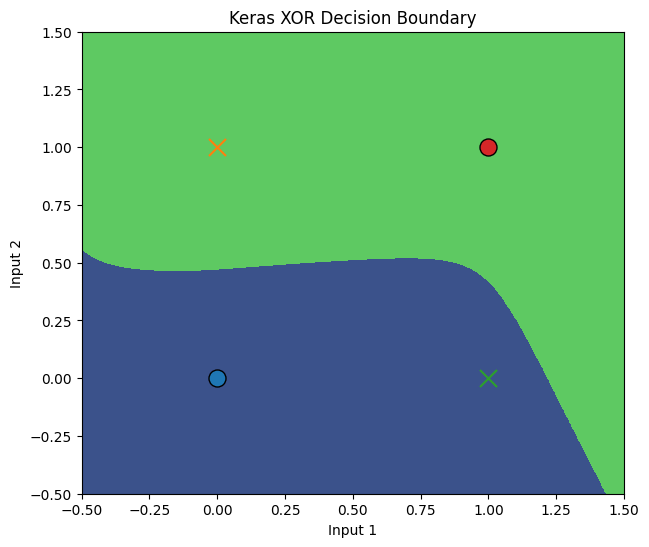

In [20]:
 plot_decision_boundary(
    keras_predict,
    "Keras XOR Decision Boundary"
)

The Keras model successfully learns the XOR pattern by creating a non-linear decision boundary that separates the two classes

**8. KERAS DECISION BOUNDARY**

/tmp/ipykernel_1350/885763245.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


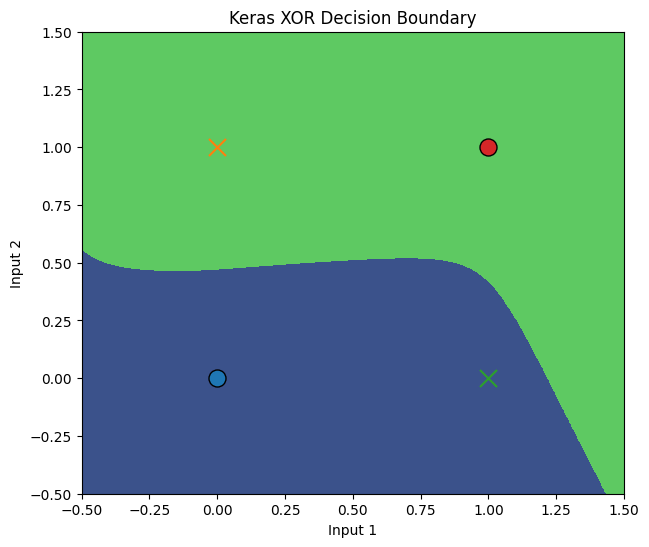

In [14]:

def keras_predict(points):

    return keras_model.predict(
        points,
        verbose=0
    )
plot_decision_boundary(
    keras_predict,
    "Keras XOR Decision Boundary"
)


**9. PYTORCH DECISION BOUNDARY**

/tmp/ipykernel_1350/885763245.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


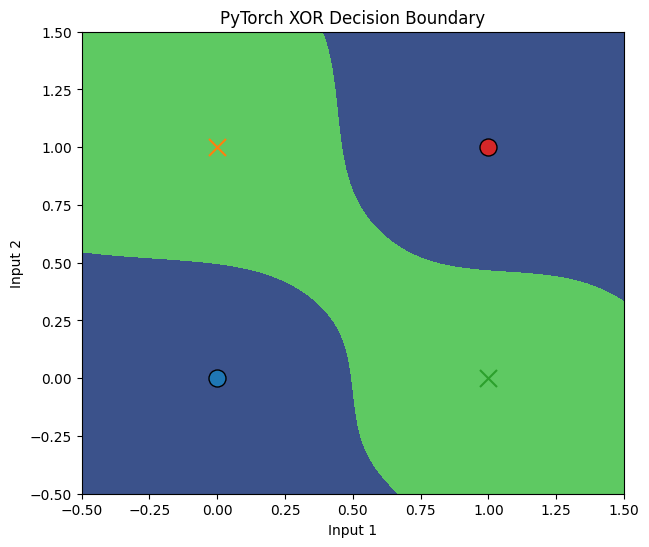

In [15]:
def torch_predict(points):

    points = torch.tensor(
        points,
        dtype=torch.float32
    )

    with torch.no_grad():
        return torch_model(points).numpy()
plot_decision_boundary(
    torch_predict,
    "PyTorch XOR Decision Boundary"
)


The PyTorch model also successfully learns the XOR pattern forming a non-linear decision boundary between the two classe

**10. TENSORFLOW LOW-LEVEL DECISION BOUNDARY**

/tmp/ipykernel_1350/885763245.py:45: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


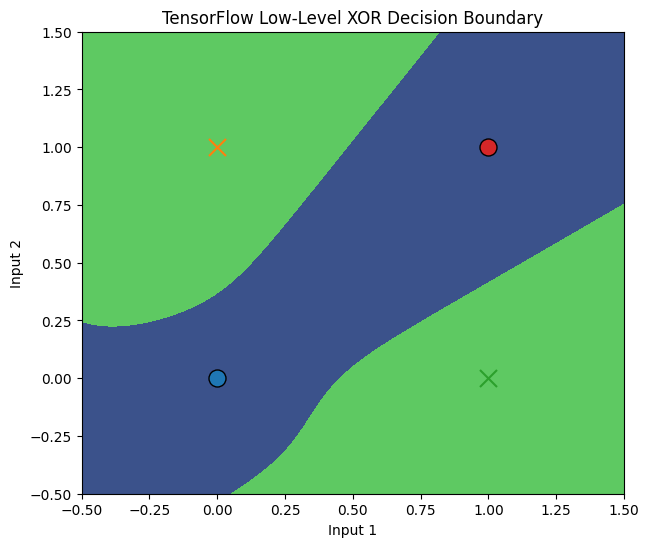

In [16]:
def tensorflow_predict(points):
    return forward_pass(points).numpy()
plot_decision_boundary(
    tensorflow_predict,
    "TensorFlow Low-Level XOR Decision Boundary"
)


The model also learns the XOR pattern but with a different non-linear boundary shape while correctly separating the classes

**11. FINAL COMPARISON TABLE**

In [17]:
keras_final_accuracy = (
    keras_history.history["accuracy"][-1] * 100
)

pytorch_final_accuracy = (
    torch_accuracies[-1] * 100
)

tensorflow_final_accuracy = (
    tf_accuracies[-1] * 100
)

print(
    "Keras Accuracy:",
    round(keras_final_accuracy, 2),
    "%"
)

print(
    "PyTorch Accuracy:",
    round(pytorch_final_accuracy, 2),
    "%"
)

print(
    "TensorFlow Low-Level Accuracy:",
    round(tensorflow_final_accuracy, 2),
    "%"
)

Keras Accuracy: 50.0 %
PyTorch Accuracy: 100.0 %
TensorFlow Low-Level Accuracy: 100.0 %


Means PyTorch and TensorFlow successfully learned the XOR function with 100% accuracy while the Keras model learned only half(50%) of the XOR cases correctly